# HOW TO: beat top-3 in Super Resolution in Video Games competition
## Score: ≈33.5

# <a id='0'>Content</a>

- <a href='#1'>Task description</a>  
- <a href='#2'>Ideas summary</a>  
- <a href='#3'>Inspect images: Choose a threshold to filter out the images</a>  
- <a href='#4'>Model</a>   
 - <a href='#5'>Prepare training files</a>   
 - <a href='#6'>Clone repositories, install requirements</a>   
 - <a href='#7'>Add PSNR filter to train file</a>   
 - <a href='#8'>Change yaml: add paths, num iterations</a>  
 - <a href='#9'>Use prepared train.py</a>   
- <a href='#10'>Inference</a>   
- <a href='#11'>Encode and submit</a>   

# <a id='1'>Task description</a>  

There are screenshots from games in poor resolution, we need to:  
- **Increase the resolution** by 4x  
- Make the picture **more “clear”**, including remove the blurring of borders  
- **Restore details**, the outlines of which are poorly recognizable (but at the same time do not add unnecessary things)  

In train dataset we have **low resolution and high resolution images**. Low resolution images are 270x480 pixels, high resolution images are 1080x1920 pixels.
In test dataset we have **low resolution images which are cropped to 64x64 pixels**. High resolution test images are not publicly available and are cropped in the same way to 256x256 pixels. The type of cropping is random paired cropping  

The key metric is **Peak Signal-to-Noise Ratio (PSNR)** between the predicted high resolution images and the observed high resolution images

### Just using the HAT-S-x4 model already allows you to beat the benchmark base. Fine-tuning allows you to beat the third place, and fine-tuning with data cleaning - the second place

# <a id='2'>Ideas summary</a>  

**Disclamer! Most of the actions in this notebook are crutches needed because of working with Kaggle**

* **check the train data**: there are pairs of pictures that don't have the same image content (e.g. hr has lighted lamps and lr doesn't). there are also many duplicates (same pairs of pictures). delete what you think is trash  

*I have deleted pairs that have PSNR (from ignit.metrics) less than 18*  

* **use augmentations in dataloader** (in addition to classical rotations we need pair crop, because we have cropped images on the test).  

*I have horizontal + vertical rotations, paired random crop*

* **take some pre-trained models** (pay attention to what it was trained on) and compare the quality specifically in this competition.  

*I checked it visually + through trial submissions (compared EDSR, ESRGAN, HAT, HAT small, Real HAT GAN).*

* **you can use [Chainner](https://chainner.app/)** to speed up inference and to test pre-trained models without fine-tuning.  

* **fine-tune the model on your own data.** for some models you need to take ready-made train.py, an example of how to work with them (for HAT) in kaggle below.  
* **the process can be paralleled** as in the examples of the model developers, but in kaggle it does not seem to be possible to do so

*I have [HAT-S_SRx4](https://github.com/XPixelGroup/HAT), prepared train.py according to instructions from model developers + ≈60,000 iterations (but part is skipped because of mismatched pictures in a pair)*

* It would be useful to also **split the data into training and validation**.  

*I didn't do that*

* In this contest the order of images in submission was initially important, adapting to this, the code for encode was taken using susmission example

In [1]:
!pip install torch torchvision torchmetrics opencv-python imagehash pyyaml

In [2]:
!pip install git+https://github.com/eugenesiow/super-image.git

  Cloning https://github.com/eugenesiow/super-image.git to /tmp/pip-req-build-yxrwedz2
  Running command git clone --filter=blob:none --quiet https://github.com/eugenesiow/super-image.git /tmp/pip-req-build-yxrwedz2
  Resolved https://github.com/eugenesiow/super-image.git to commit 50439eade7be6f9756783f514c07aa16283c31ca
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for super-image: filename=super_image-0.1.7-py3-none-any.whl size=91055 sha256=4ba6260a3c89319f12e03f90e958d986e9ce56a22dcab5ac28149e6f5738bad0
  Stored in directory: /tmp/pip-ephem-wheel-cache-msza0rv0/wheels/c3/e3/d0/b0893567d94b8368196d7b5a4ec006eb8c5101ec9f872c009b
Successfully built super-image


In [3]:
import os
import numpy as np
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from ignite.metrics import PSNR
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision import transforms
from super_image import EdsrModel
import imagehash

/opt/conda/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 1.4.15 (you have 1.4.14). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
/opt/conda/lib/python3.10/site-packages/ignite/handlers/checkpoint.py:16: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


# <a id='3'>Inspect images</a>  
Choose a threshold to filter out the images

In [4]:
with open("/kaggle/input/suspects/suspects_to_choose_threshold.txt", "r", encoding="utf-8") as file:
    suspects = file.readlines()

# Удаляем символ переноса строки из каждой строки (если он есть)
suspects = [suspect.strip() for suspect in suspects]

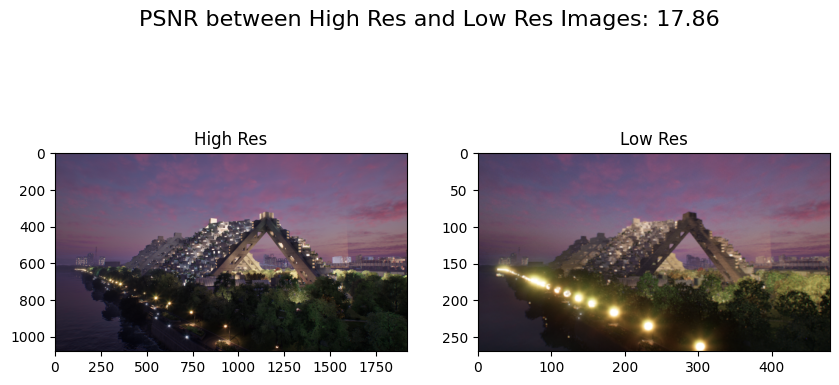

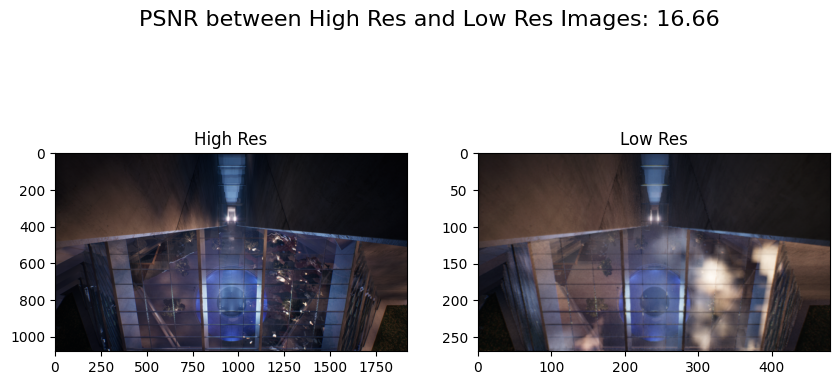

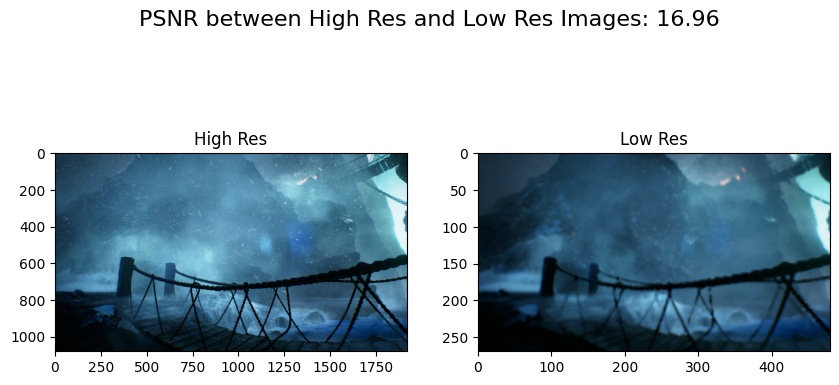

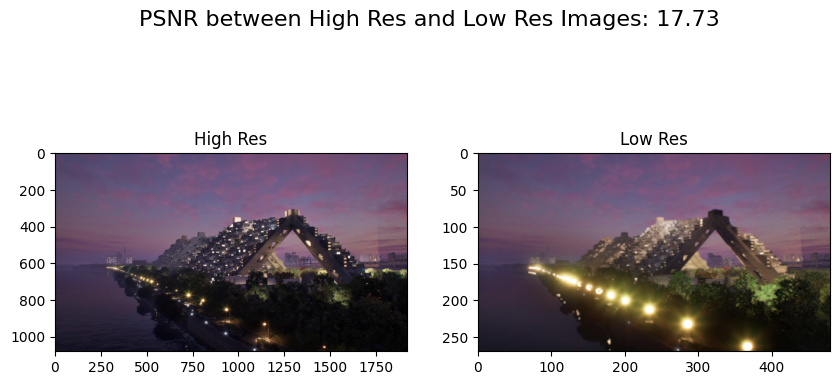

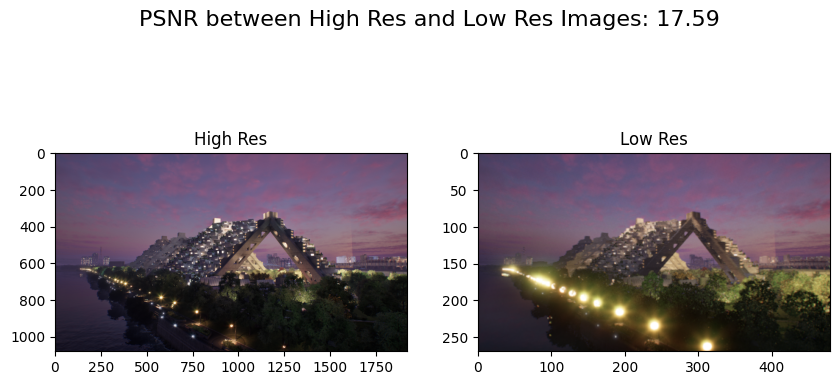

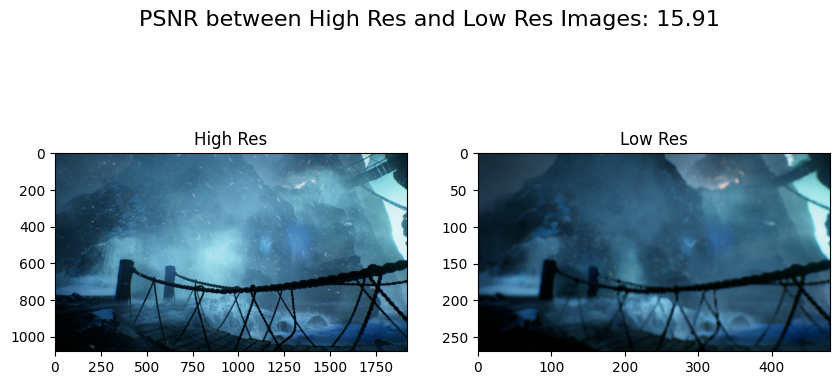

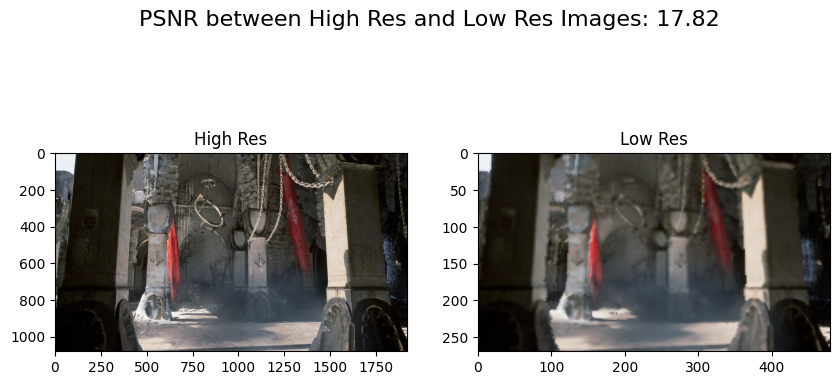

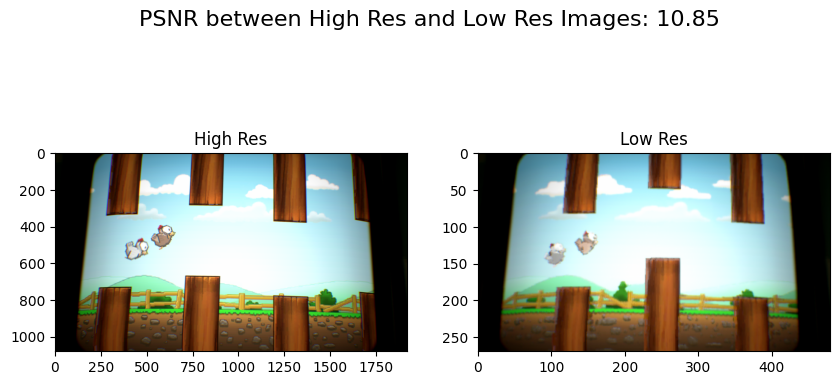

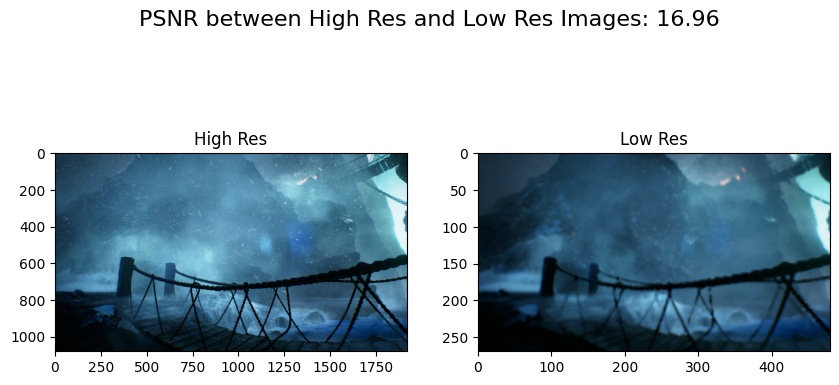

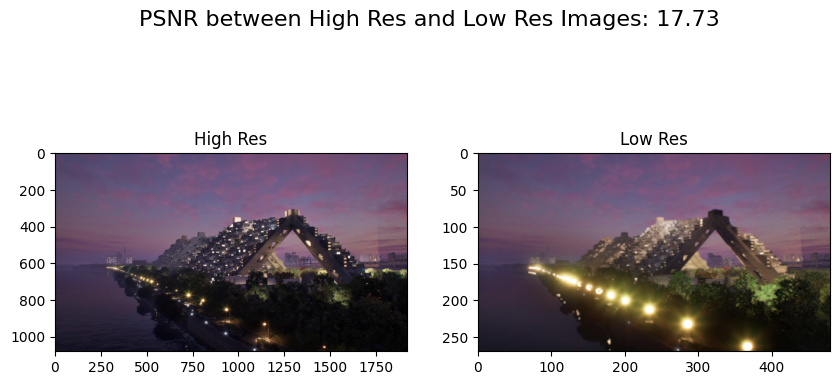

In [5]:
def inspect_psnr_pairs(high_res_dir, low_res_dir, 
                       mismatched_pairs, num_samples=10):
    counter = 0
    for pair_name in mismatched_pairs:
        if counter == num_samples:
            break
        hr_path = os.path.join(high_res_dir, pair_name)
        lr_path = os.path.join(low_res_dir, pair_name)

        hr_img = Image.open(hr_path).convert("RGB")
        lr_img = Image.open(lr_path).convert("RGB")
        
        # Resize images to 256x256 for PSNR check
        high_res_image_resized = hr_img.resize((256, 256), Image.BICUBIC)
        low_res_image_resized = lr_img.resize((256, 256), Image.BICUBIC)

        # Convert to numpy array
        high_res_image_resized = np.array(high_res_image_resized)
        low_res_image_resized = np.array(low_res_image_resized)

        # Calculate PSNR
        psnr_metric = PSNR(data_range=255)
        psnr_metric.update((torch.tensor(high_res_image_resized).unsqueeze(0), torch.tensor(low_res_image_resized).unsqueeze(0)))
        psnr_value = psnr_metric.compute()
        psnr_metric.reset()
        
        if psnr_value <= 18:
            counter += 1
            fig, axs = plt.subplots(1, 2, figsize=(10, 5))
            axs[0].imshow(hr_img)
            axs[0].set_title('High Res')
            axs[1].imshow(lr_img)
            axs[1].set_title('Low Res')
            fig.suptitle(f'PSNR between High Res and Low Res Images: {psnr_value:.2f}', fontsize=16)
            psnr_value
            plt.show()

# Пример использования
inspect_psnr_pairs('/kaggle/input/super-resolution-in-video-games/train/hr', 
                   '/kaggle/input/super-resolution-in-video-games/train/lr', 
                   suspects)

# <a id='4'>Model</a>

## <a id='5'>Prepare training files</a>

### <a id='6'>Clone repositories, install requirements</a>

In [1]:
!git clone https://github.com/XPixelGroup/HAT.git

Cloning into 'HAT'...
remote: Enumerating objects: 419, done.
remote: Counting objects: 100% (270/270), done.
remote: Compressing objects: 100% (127/127), done.
remote: Total 419 (delta 223), reused 144 (delta 143), pack-reused 149 (from 1)
Receiving objects: 100% (419/419), 20.72 MiB | 36.89 MiB/s, done.
Resolving deltas: 100% (233/233), done.


In [2]:
%cd HAT

/kaggle/working/HAT


In [3]:
!pip install -r requirements.txt
!python setup.py develop

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 1.6 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 5.1 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 34.9 MB/s eta 0:00:0000:0100:01
  Created wheel for basicsr: filename=basicsr-1.3.4.9-py3-none-any.whl size=194421 sha256=4e2a761b243308fedcd2b83bad02068bfd9846ecad4986270e4ba0fbaf338411
  Stored in directory: /root/.cache/pip/wheels/37/19/97/8206d928857f2ef0625cb621b689005610515b4841be4e5ddb
Successfully built basicsr
/opt/conda/lib/python3.10/site-packages/setuptools/__init__.py:80: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
!!

        ********************************************************************************
        Requirements should be satisfied by a PEP 517 installer.
        If you are u

### <a id='7'>Add PSNR filter to train file</a>

We **cannot remove bad pairs from folders in kaggle input** because it is an unchangeable object. Also, it is **not possible to save cleaned folders in kaggle working** because there is not enough memory. Therefore, let's make a crutch and **skip the learning iteration** if PSNR is lower than 18

In [4]:
%%bash
echo """
import datetime
import logging
import math
import time
import torch
import torch.nn.functional as F

from os import path as osp

from basicsr.data import build_dataloader, build_dataset
from basicsr.data.data_sampler import EnlargedSampler
from basicsr.data.prefetch_dataloader import CPUPrefetcher, CUDAPrefetcher
from basicsr.models import build_model
from basicsr.utils import (AvgTimer, MessageLogger, check_resume, get_env_info, get_root_logger, get_time_str,
                           init_tb_logger, init_wandb_logger, make_exp_dirs, mkdir_and_rename, scandir)
from basicsr.utils.options import copy_opt_file, dict2str, parse_options

from ignite.metrics import PSNR


def init_tb_loggers(opt):
    # initialize wandb logger before tensorboard logger to allow proper sync
    if (opt['logger'].get('wandb') is not None) and (opt['logger']['wandb'].get('project')
                                                     is not None) and ('debug' not in opt['name']):
        assert opt['logger'].get('use_tb_logger') is True, ('should turn on tensorboard when using wandb')
        init_wandb_logger(opt)
    tb_logger = None
    if opt['logger'].get('use_tb_logger') and 'debug' not in opt['name']:
        tb_logger = init_tb_logger(log_dir=osp.join(opt['root_path'], 'tb_logger', opt['name']))
    return tb_logger


def create_train_val_dataloader(opt, logger):
    # create train and val dataloaders
    train_loader, val_loaders = None, []
    for phase, dataset_opt in opt['datasets'].items():
        if phase == 'train':
            dataset_enlarge_ratio = dataset_opt.get('dataset_enlarge_ratio', 1)
            train_set = build_dataset(dataset_opt)
            train_sampler = EnlargedSampler(train_set, opt['world_size'], opt['rank'], dataset_enlarge_ratio)
            train_loader = build_dataloader(
                train_set,
                dataset_opt,
                num_gpu=opt['num_gpu'],
                dist=opt['dist'],
                sampler=train_sampler,
                seed=opt['manual_seed'])

            num_iter_per_epoch = math.ceil(
                len(train_set) * dataset_enlarge_ratio / (dataset_opt['batch_size_per_gpu'] * opt['world_size']))
            total_iters = int(opt['train']['total_iter'])
            total_epochs = math.ceil(total_iters / (num_iter_per_epoch))
            logger.info('Training statistics:' +
                        f'\n\tNumber of train images: {len(train_set)}' +
                        f'\n\tDataset enlarge ratio: {dataset_enlarge_ratio}' +
                        '\n\tBatch size per gpu: {}'.format(dataset_opt['batch_size_per_gpu']) +
                        '\n\tWorld size (gpu number): {}'.format(opt['world_size']) +
                        f'\n\tRequire iter number per epoch: {num_iter_per_epoch}' +
                        f'\n\tTotal epochs: {total_epochs}; iters: {total_iters}.')
        elif phase.split('_')[0] == 'val':
            val_set = build_dataset(dataset_opt)
            val_loader = build_dataloader(
                val_set, dataset_opt, num_gpu=opt['num_gpu'], dist=opt['dist'], sampler=None, seed=opt['manual_seed'])
            logger.info('Number of val images/folders in {}: {}'.format(dataset_opt['name'], len(val_set)))
            val_loaders.append(val_loader)
        else:
            raise ValueError(f'Dataset phase {phase} is not recognized.')

    return train_loader, train_sampler, val_loaders, total_epochs, total_iters


def load_resume_state(opt):
    resume_state_path = None
    if opt['auto_resume']:
        state_path = osp.join('experiments', opt['name'], 'training_states')
        if osp.isdir(state_path):
            states = list(scandir(state_path, suffix='state', recursive=False, full_path=False))
            if len(states) != 0:
                states = [float(v.split('.state')[0]) for v in states]
                resume_state_path = osp.join(state_path, f'{max(states):.0f}.state')
                opt['path']['resume_state'] = resume_state_path
    else:
        if opt['path'].get('resume_state'):
            resume_state_path = opt['path']['resume_state']

    if resume_state_path is None:
        resume_state = None
    else:
        device_id = torch.cuda.current_device()
        resume_state = torch.load(resume_state_path, map_location=lambda storage, loc: storage.cuda(device_id))
        check_resume(opt, resume_state['iter'])
    return resume_state


def train_pipeline(root_path):
    # parse options, set distributed setting, set ramdom seed
    opt, args = parse_options(root_path, is_train=True)
    opt['root_path'] = root_path

    torch.backends.cudnn.benchmark = True
    # torch.backends.cudnn.deterministic = True

    # load resume states if necessary
    resume_state = load_resume_state(opt)
    # mkdir for experiments and logger
    if resume_state is None:
        make_exp_dirs(opt)
        if opt['logger'].get('use_tb_logger') and 'debug' not in opt['name'] and opt['rank'] == 0:
            mkdir_and_rename(osp.join(opt['root_path'], 'tb_logger', opt['name']))

    # copy the yml file to the experiment root
    copy_opt_file(args.opt, opt['path']['experiments_root'])

    # WARNING: should not use get_root_logger in the above codes, including the called functions
    # Otherwise the logger will not be properly initialized
    log_file = osp.join(opt['path']['log'], 'train_{}_{}.log'.format(opt['name'], get_time_str()))
    logger = get_root_logger(logger_name='basicsr', log_level=logging.INFO, log_file=log_file)
    logger.info(get_env_info())
    logger.info(dict2str(opt))
    # initialize wandb and tb loggers
    tb_logger = init_tb_loggers(opt)

    # create train and validation dataloaders
    result = create_train_val_dataloader(opt, logger)
    train_loader, train_sampler, val_loaders, total_epochs, total_iters = result

    # create model
    model = build_model(opt)
    if resume_state:  # resume training
        model.resume_training(resume_state)  # handle optimizers and schedulers
        logger.info('Resuming training from epoch: {}, '.format(resume_state['epoch']) + 'iter: {}.'.format(resume_state['iter']))
        start_epoch = resume_state['epoch']
        current_iter = resume_state['iter']
    else:
        start_epoch = 0
        current_iter = 0

    # create message logger (formatted outputs)
    msg_logger = MessageLogger(opt, current_iter, tb_logger)

    # dataloader prefetcher
    prefetch_mode = opt['datasets']['train'].get('prefetch_mode')
    if prefetch_mode is None or prefetch_mode == 'cpu':
        prefetcher = CPUPrefetcher(train_loader)
    elif prefetch_mode == 'cuda':
        prefetcher = CUDAPrefetcher(train_loader, opt)
        logger.info(f'Use {prefetch_mode} prefetch dataloader')
        if opt['datasets']['train'].get('pin_memory') is not True:
            raise ValueError('Please set pin_memory=True for CUDAPrefetcher.')
    else:
        raise ValueError(f'Wrong prefetch_mode {prefetch_mode}.' 'Supported ones are: None, cuda, cpu.')

    # training
    logger.info(f'Start training from epoch: {start_epoch}, iter: {current_iter}')
    data_timer, iter_timer = AvgTimer(), AvgTimer()
    start_time = time.time()

    for epoch in range(start_epoch, total_epochs + 1):
        train_sampler.set_epoch(epoch)
        prefetcher.reset()
        train_data = prefetcher.next()
        while train_data is not None:
            data_timer.record()

            current_iter += 1
            if current_iter > total_iters:
                break
            # Calculate PSNR
            device = train_data['gt'].device
            psnr_metric = PSNR(data_range=255) #.to(device)
            
            psnr_metric.update((F.interpolate(train_data['gt'], size=(256, 256), mode='bilinear', align_corners=False).unsqueeze(0), F.interpolate(train_data['lq'], size=(256, 256), mode='bilinear', align_corners=False).unsqueeze(0)))
            psnr_value = psnr_metric.compute()
            psnr_metric.reset()
            
            if psnr_value >= 18:
                # update learning rate
                model.update_learning_rate(current_iter, warmup_iter=opt['train'].get('warmup_iter', -1))
            
                # training
                model.feed_data(train_data)
                model.optimize_parameters(current_iter)

                iter_timer.record()
                if current_iter == 1:
                    # reset start time in msg_logger for more accurate eta_time
                    # not work in resume mode
                    msg_logger.reset_start_time()
                # log
                if current_iter % opt['logger']['print_freq'] == 0:
                    log_vars = {'epoch': epoch, 'iter': current_iter}
                    log_vars.update({'lrs': model.get_current_learning_rate()})
                    log_vars.update({'time': iter_timer.get_avg_time(), 'data_time': data_timer.get_avg_time()})
                    log_vars.update(model.get_current_log())
                    msg_logger(log_vars)

                # save models and training states
                if current_iter % opt['logger']['save_checkpoint_freq'] == 0:
                    logger.info('Saving models and training states.')
                    model.save(epoch, current_iter)

                # validation
                if opt.get('val') is not None and (current_iter % opt['val']['val_freq'] == 0):
                    if len(val_loaders) > 1:
                        logger.warning('Multiple validation datasets are *only* supported by SRModel.')
                    for val_loader in val_loaders:
                        model.validation(val_loader, current_iter, tb_logger, opt['val']['save_img'])

                data_timer.start()
                iter_timer.start()
                train_data = prefetcher.next()
            else:
                if current_iter == 1:
                    msg_logger.reset_start_time()
                iter_timer.record()
                log_vars = {'epoch': epoch, 'iter': current_iter}
                if current_iter % opt['logger']['print_freq'] == 0:
                    msg_logger(log_vars)
            # end of iter

    # end of epoch

    consumed_time = str(datetime.timedelta(seconds=int(time.time() - start_time)))
    logger.info(f'End of training. Time consumed: {consumed_time}')
    logger.info('Save the latest model.')
    model.save(epoch=-1, current_iter=-1)  # -1 stands for the latest
    if opt.get('val') is not None:
        for val_loader in val_loaders:
            model.validation(val_loader, current_iter, tb_logger, opt['val']['save_img'])
    if tb_logger:
        tb_logger.close()


if __name__ == '__main__':
    root_path = osp.abspath(osp.join(__file__, osp.pardir, osp.pardir))
    train_pipeline(root_path)
""" > /opt/conda/lib/python3.10/site-packages/basicsr/train.py

### <a id='8'>Change yaml: add paths, num iterations</a>

### Lifehack how to do fine tuning of a pre-trained model in kaggle:

1) start fine-tuning a pre-trained loaded model **so that at the moment of finishing you can save the model to your computer** (fine-tuned model will appear in the folder /kaggle/working/HAT/experiments -> name of your experiment specified in the config. *mine is train_HAT-S_SRx4_finetune_from_SRx2)*

*for me 3000 iterations took about an hour*

2) **upload the saved model back to the notebook and train it again** (by changing the path to the model in the config).

In [ ]:
NUM_ITERATIONS = 24000
MODEL_PATH = '/kaggle/input/hat-s_srx4-clean-6/pytorch/default/1/HAT-S_SRx4-clean-6.pth'

In [5]:
import yaml 

file_path = '/kaggle/working/HAT/options/train/train_HAT-S_SRx4_finetune_from_SRx2.yml'

with open(file_path, 'r') as file:
    data = yaml.safe_load(file)

# Меняем данные
data['datasets']['train'] = {
    'name': 'SR in Video Games',
    'type': 'PairedImageDataset',
    'dataroot_gt': '/kaggle/input/super-resolution-in-video-games/train/hr',
    'dataroot_lq': '/kaggle/input/super-resolution-in-video-games/train/lr',
    'io_backend': {
        'type': 'disk'
        },
    'gt_size': 256,
    'use_hflip': True,
    'use_rot': True,

    # data loader
    'use_shuffle': True,
    'num_worker_per_gpu': 2,
    'batch_size_per_gpu': 4,
    'dataset_enlarge_ratio': 1,
    'prefetch_mode': 'cuda',
    'pin_memory': True
}

data['train']['total_iter'] = NUM_ITERATIONS
data['num_gpu'] = 1
data['pbar'] = True
data['path']['pretrain_network_g'] = MODEL_PATH

# Удаление валидационной части
for val in ['val', 'val_2', 'val_3']:
    if val in data['datasets']:
        del data['datasets'][val]

# Запись измененных данных обратно в файл
with open(file_path, 'w') as file:
    yaml.safe_dump(data, file)

**Fix bugs**

In [6]:
!sed -i 's/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/' /opt/conda/lib/python3.10/site-packages/basicsr/data/degradations.py

## <a id='9'>Use prepared train.py</a>

In [7]:
!python hat/train.py -opt options/train/train_HAT-S_SRx4_finetune_from_SRx2.yml

/opt/conda/lib/python3.10/site-packages/ignite/handlers/checkpoint.py:16: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer
Disable distributed.
2024-09-14 12:08:08,245 INFO: 
                ____                _       _____  ____
               / __ ) ____ _ _____ (_)_____/ ___/ / __ \
              / __  |/ __ `// ___// // ___/\__ \ / /_/ /
             / /_/ // /_/ /(__  )/ // /__ ___/ // _, _/
            /_____/ \__,_//____//_/ \___//____//_/ |_|
     ______                   __   __                 __      __
    / ____/____   ____   ____/ /  / /   __  __ _____ / /__   / /
   / / __ / __ \ / __ \ / __  /  / /   / / / // ___// //_/  / /
  / /_/ // /_/ // /_/ // /_/ /  / /___/ /_/ // /__ / /<    /_/
  \____/ \____/ \____/ \____/  /_____/\____/ \___//_/|_|  (_)
    
Version Information: 


# <a id='10'>Inference</a> 
Use chainner (screen below) or this code may be helpful

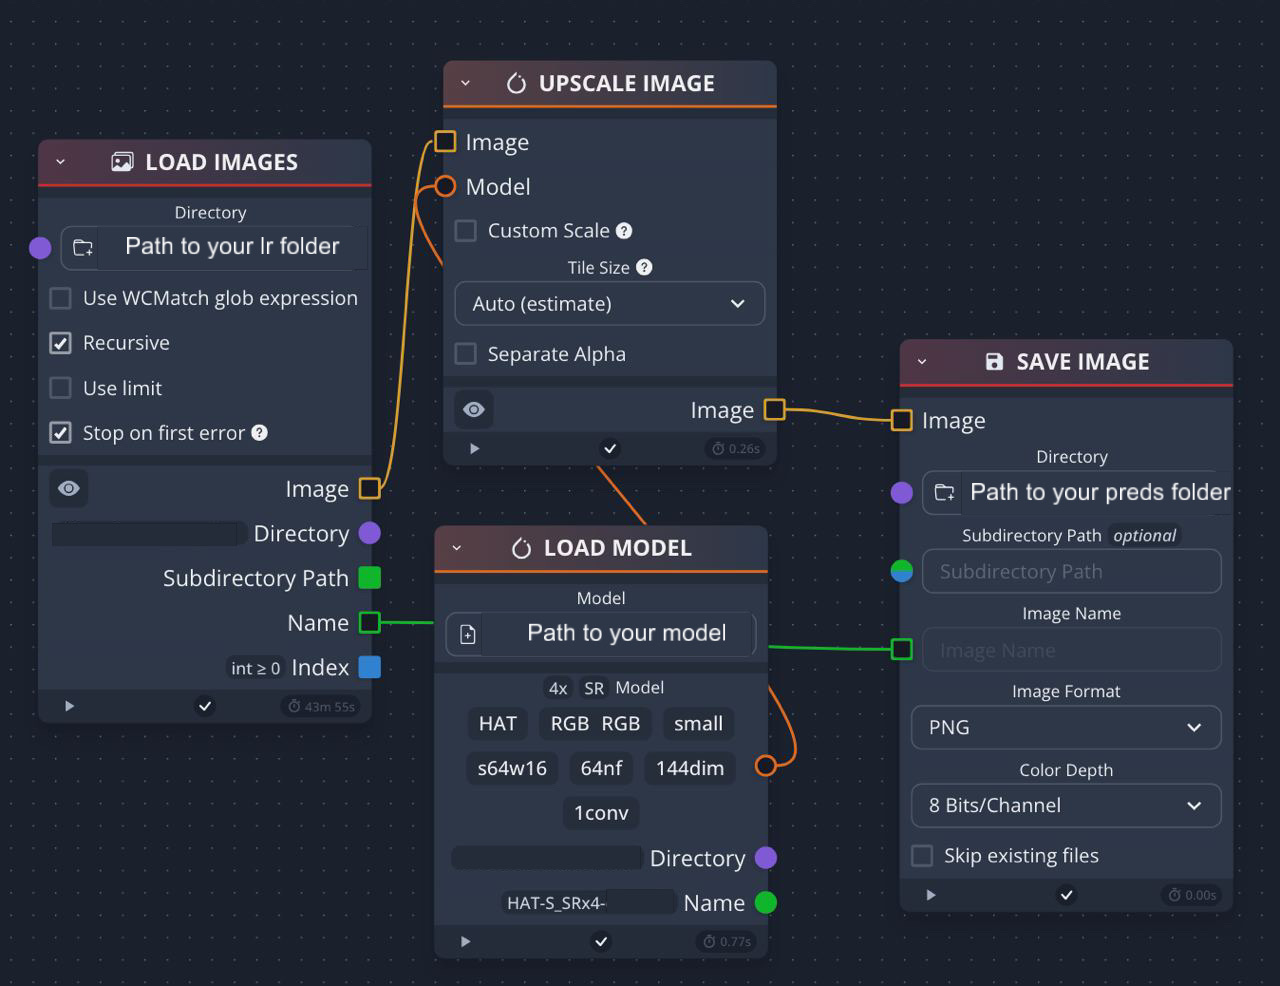

In [1]:
from IPython.display import Image
image_path = "/kaggle/input/chainner-example/IMG_0573.JPEG"
Image(filename=image_path)

In [ ]:
class TestDataset(Dataset):
    def __init__(self, test_folder, transform=None):
        self.test_folder = test_folder
        self.transform = transform
        self.filenames = os.listdir(test_folder)

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_path = os.path.join(self.test_folder, self.filenames[idx])
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.filenames[idx]

model.eval()

# Путь к папке с тестовыми изображениями
test_folder = '/kaggle/input/super-resolution-in-video-games/test/lr'

# Преобразования для данных
transform = transforms.Compose([
    transforms.ToTensor()
])

# Создание Dataset и DataLoader
test_dataset = TestDataset(test_folder, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

predictions = []
filenames = []
ids = []

# Проход по всем батчам в DataLoader с использованием tqdm для отображения прогресса
for batch_idx, (data, filename) in enumerate(tqdm(test_loader, desc="Predicting")):
    data = data.to(device)

    # Предикт с использованием модели
    with torch.no_grad():
        prediction = model(data)

    # Преобразование тензора в массив numpy
    prediction = prediction.permute(0, 2, 3, 1).cpu().numpy()
    prediction = (prediction * 255).astype('uint8')

    # Кодирование изображений
    for i in range(prediction.shape[0]):
        encoded_prediction = encode(prediction[i])
        predictions.append(encoded_prediction)
        filenames.append(filename[i])
        ids.append(batch_idx * test_loader.batch_size + i)

# Создание DataFrame для сабмита
submission = pd.DataFrame({
    'id': ids,
    'filename': filenames,
    'rle': predictions
})

# Сохранение результатов в CSV файл
submission.to_csv('submission.csv', index=False)

# <a id='11'>Encode and submit (if using Chainner)</a>

In [ ]:
import base64
import zlib

import cv2
import numpy as np

import os
from PIL import Image

import pandas as pd

from tqdm import tqdm

def encode(img: np.ndarray) -> bytes:
    """
    Lossless encoding of images for submission on kaggle platform.

    Parameters
    ----------
    img : np.ndarray
        cv2.imread(f) - BGR image in (h, w, c) format, c = 3 (even for png format).
        
    Returns
    -------
    bytes
        Encoded image as bytes.
    """
    img_to_encode = img.astype(np.uint8)
    img_to_encode = img_to_encode.flatten()
    img_to_encode = np.append(img_to_encode, -1)

    cnt, rle = 1, []
    for i in range(1, img_to_encode.shape[0]):
        if img_to_encode[i] == img_to_encode[i - 1]:
            cnt += 1
            if cnt > 255:
                rle += [img_to_encode[i - 1], 255]
                cnt = 1
        else:
            rle += [img_to_encode[i - 1], cnt]
                        cnt = 1

    compressed = zlib.compress(bytes(rle), zlib.Z_BEST_COMPRESSION)
    base64_bytes = base64.b64encode(compressed)
    return base64_bytes

In [ ]:
def prediction(
    sample_submission: str,
    lr_folder: str,
    output_file: str
) -> None:
    """
    Get prediction for sample submission using huggingface model.

    Parameters
    ----------
    sample_submission : str
        Path to sample submission file.
    lr_folder : str
        Path to test dataset folder with LR images.
    output_file : str
        Path to output file with predictions.
    model : str
        Name (repository) of huggingface model.
    device : str
        Device on which the model will be run.
    simple_resize : str
            If specified then the upscaling will be done using deterministic interpolation.

    Returns
    -------
    None
    """
    submission_df = pd.read_csv(sample_submission)

    filenames = submission_df["filename"].values
    for i in tqdm(range(len(filenames))):
        filename = filenames[i]
        init_img = cv2.imread(os.path.join(lr_folder, filename))
        submission_df.loc[i, "rle"] = encode(init_img)
    submission_df.to_csv(output_file, index=False)

In [ ]:
prediction(
    sample_submission= 'your_path_to/sample_submission.csv',
    lr_folder= 'your_path_to/hr',
    output_file= f'your_path_to/{NUM_ITERATIONS}it_submission.csv'
)